# Auto Price Prediction

## Problem Statement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('auto_imports.csv')

In [3]:
data.head()

,Symboling,Normalized_losses,Carname,Fueltype,Aspiration,Door_num,Body_style,Drive_wheels,Engine_location,Wheel_base,...,Engine_size,Fuelsystem,Bore,Stroke,Compression_ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


## Domain Analysis

## Basic Checks

In [4]:
data.shape

(201, 26)

In [5]:
data.head()

,Symboling,Normalized_losses,Carname,Fueltype,Aspiration,Door_num,Body_style,Drive_wheels,Engine_location,Wheel_base,...,Engine_size,Fuelsystem,Bore,Stroke,Compression_ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [6]:
data.tail()

,Symboling,Normalized_losses,Carname,Fueltype,Aspiration,Door_num,Body_style,Drive_wheels,Engine_location,Wheel_base,...,Engine_size,Fuelsystem,Bore,Stroke,Compression_ratio,Horsepower,Peak_rpm,City_mpg,Highway_mpg,Price
196,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
197,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
198,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
199,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106,4800,26,27,22470
200,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625


In [7]:
data.columns

Index(['Symboling', 'Normalized_losses', 'Carname', 'Fueltype', 'Aspiration',
       'Door_num', 'Body_style', 'Drive_wheels', 'Engine_location',
       'Wheel_base', 'Length', 'Width', 'Height', 'Curb_weight', 'Engine_type',
       'Cylinders_num', 'Engine_size', 'Fuelsystem', 'Bore', 'Stroke',
       'Compression_ratio', 'Horsepower', 'Peak_rpm', 'City_mpg',
       'Highway_mpg', 'Price'],
      dtype='object')

In [8]:
data.dtypes

Symboling              int64
Normalized_losses     object
Carname               object
Fueltype              object
Aspiration            object
Door_num              object
Body_style            object
Drive_wheels          object
Engine_location       object
Wheel_base           float64
Length               float64
Width                float64
Height               float64
Curb_weight            int64
Engine_type           object
Cylinders_num         object
Engine_size            int64
Fuelsystem            object
Bore                  object
Stroke                object
Compression_ratio    float64
Horsepower            object
Peak_rpm              object
City_mpg               int64
Highway_mpg            int64
Price                  int64
dtype: object

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Symboling          201 non-null    int64  
 1   Normalized_losses  201 non-null    object 
 2   Carname            201 non-null    object 
 3   Fueltype           201 non-null    object 
 4   Aspiration         201 non-null    object 
 5   Door_num           201 non-null    object 
 6   Body_style         201 non-null    object 
 7   Drive_wheels       201 non-null    object 
 8   Engine_location    201 non-null    object 
 9   Wheel_base         201 non-null    float64
 10  Length             201 non-null    float64
 11  Width              201 non-null    float64
 12  Height             201 non-null    float64
 13  Curb_weight        201 non-null    int64  
 14  Engine_type        201 non-null    object 
 15  Cylinders_num      201 non-null    object 
 16  Engine_size        201 non

In [10]:
data.describe()

,Symboling,Wheel_base,Length,Width,Height,Curb_weight,Engine_size,Compression_ratio,City_mpg,Highway_mpg,Price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,10.164279,25.179104,30.686567,13207.129353
std,1.254802,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,4.004965,6.423220,6.815150,7947.066342
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,8.600000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,9.400000,30.000000,34.000000,16500.000000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000,45400.000000


In [11]:
data.isnull().sum()                                      ## There are No Null values

Symboling            0
Normalized_losses    0
Carname              0
Fueltype             0
Aspiration           0
Door_num             0
Body_style           0
Drive_wheels         0
Engine_location      0
Wheel_base           0
Length               0
Width                0
Height               0
Curb_weight          0
Engine_type          0
Cylinders_num        0
Engine_size          0
Fuelsystem           0
Bore                 0
Stroke               0
Compression_ratio    0
Horsepower           0
Peak_rpm             0
City_mpg             0
Highway_mpg          0
Price                0
dtype: int64

In [12]:
data.duplicated().sum()                               # There are No Duplicate Values

0

In [13]:
data['Normalized_losses'].unique()

array(['?', '164', '158', '192', '188', '121', '98', '81', '118', '148',
       '110', '145', '137', '101', '78', '106', '85', '107', '104', '113',
       '150', '129', '115', '93', '142', '161', '153', '125', '128',
       '122', '103', '168', '108', '194', '231', '119', '154', '74',
       '186', '83', '102', '89', '87', '77', '91', '134', '65', '197',
       '90', '94', '256', '95'], dtype=object)

In [14]:
data['Symboling'].unique()

array([ 3,  1,  2,  0, -1, -2], dtype=int64)

In [15]:
data['Carname'].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'mercedes-benz', 'mercury',
       'mitsubishi', 'nissan', 'peugot', 'plymouth', 'porsche', 'renault',
       'saab', 'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

In [16]:
data['Fueltype'].unique()

array(['gas', 'diesel'], dtype=object)

In [17]:
data['Fueltype'].value_counts()

Fueltype
gas       181
diesel     20
Name: count, dtype: int64

In [18]:
data['Aspiration'].unique()

array(['std', 'turbo'], dtype=object)

In [19]:
data['Aspiration'].value_counts()

Aspiration
std      165
turbo     36
Name: count, dtype: int64

In [20]:
data['Door_num'].unique()

array(['two', 'four'], dtype=object)

In [21]:
data['Body_style'].unique()

array(['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop'],
      dtype=object)

In [22]:
data['Drive_wheels'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

In [23]:
data['Engine_location'].unique()

array(['front', 'rear'], dtype=object)

In [24]:
data['Cylinders_num'].unique()

array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

# Exploratory Data Analysis

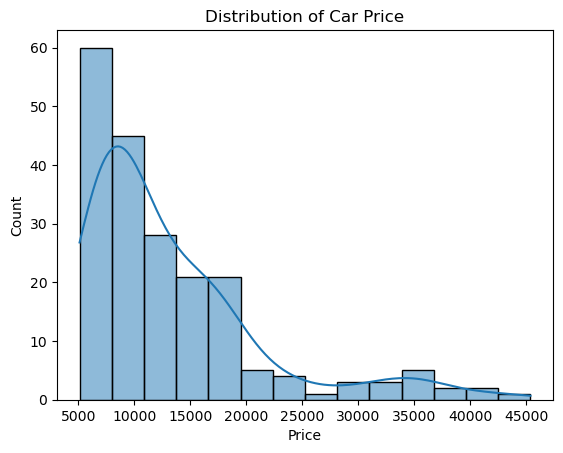

In [25]:
# Plot for Price Distribution --- Histplot

sns.histplot(data=data,x='Price',kde=True)
plt.title("Distribution of Car Price")
plt.show()

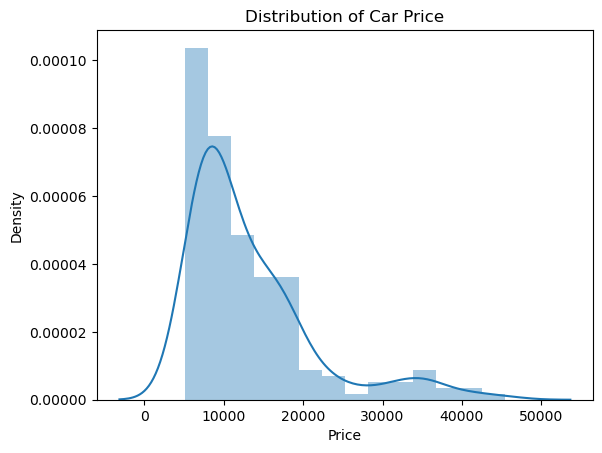

In [26]:
sns.distplot(data['Price'],kde=True)
plt.title("Distribution of Car Price")
plt.show()

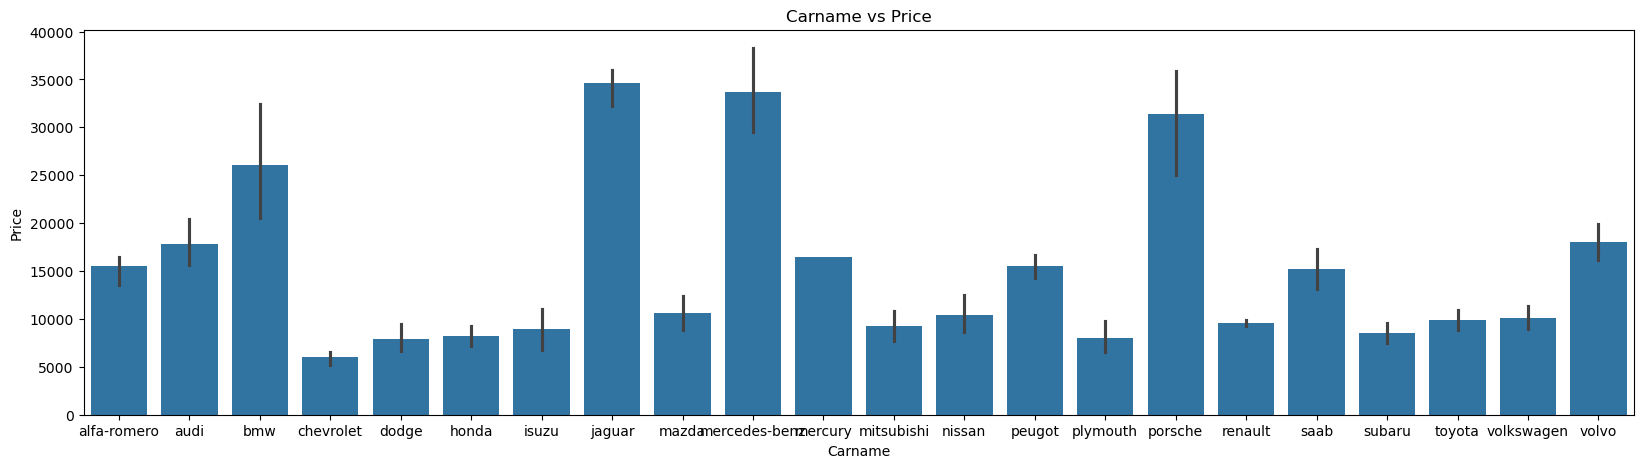

In [27]:
# Carname vs Price

plt.figure(figsize=(20,5))
sns.barplot(x='Carname', y='Price', data=data)
plt.title('Carname vs Price')
plt.show()

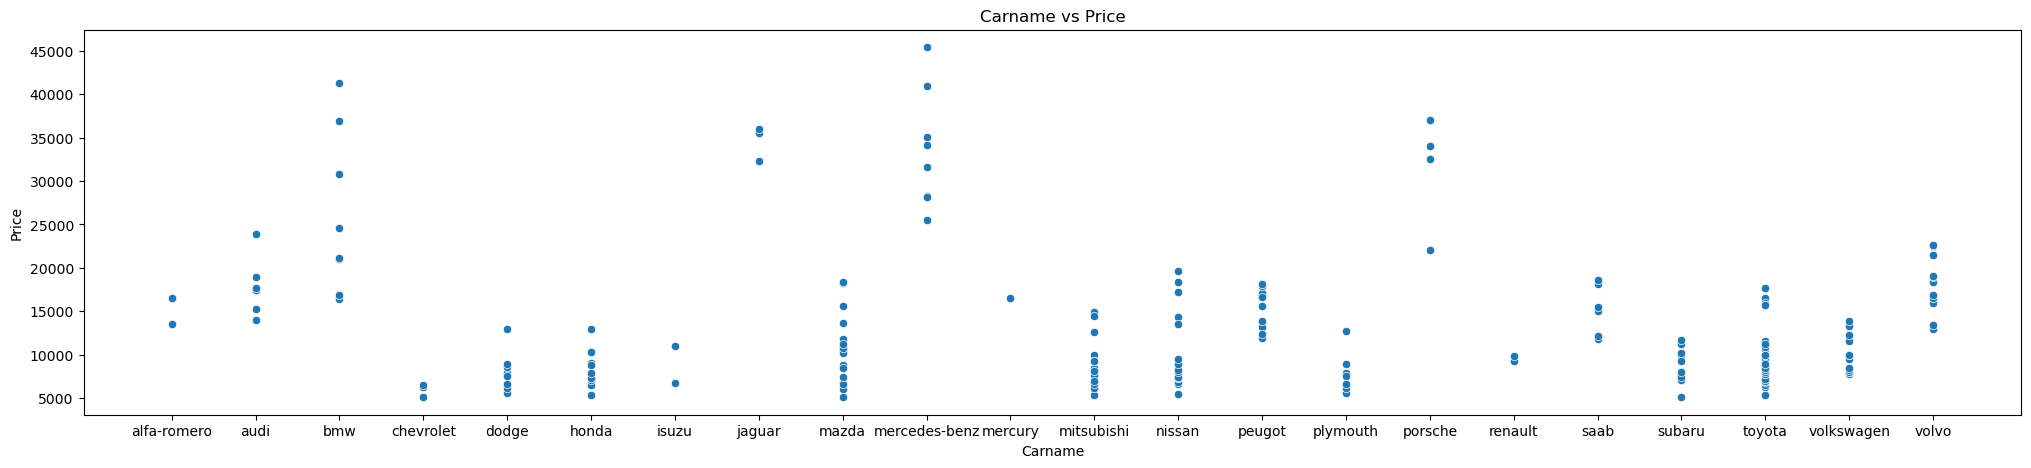

In [28]:
plt.figure(figsize=(25,5))
sns.scatterplot(x='Carname', y='Price', data=data)
plt.title('Carname vs Price')
plt.show()

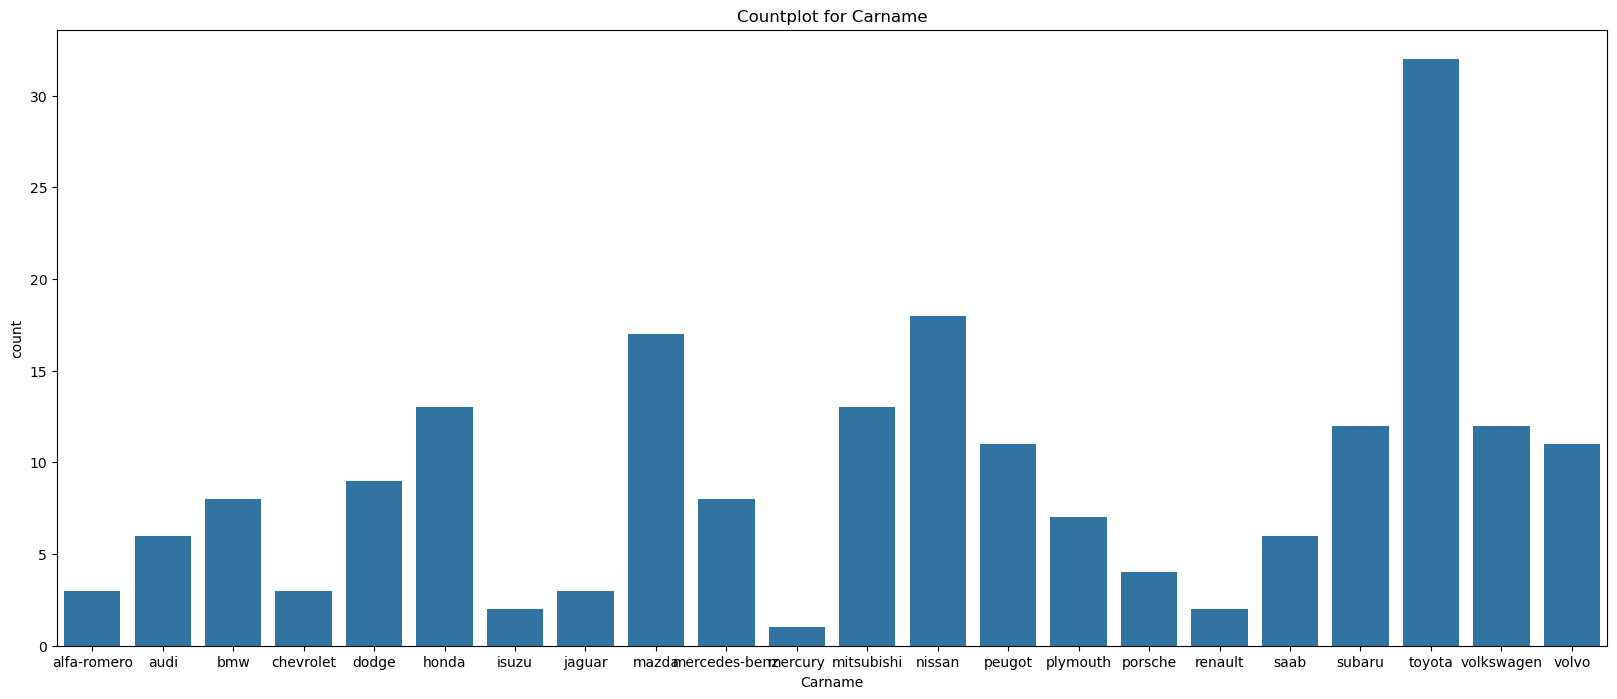

In [29]:
plt.figure(figsize=(20,8))
sns.countplot(data=data, x='Carname')
plt.title('Countplot for Carname')
plt.show()

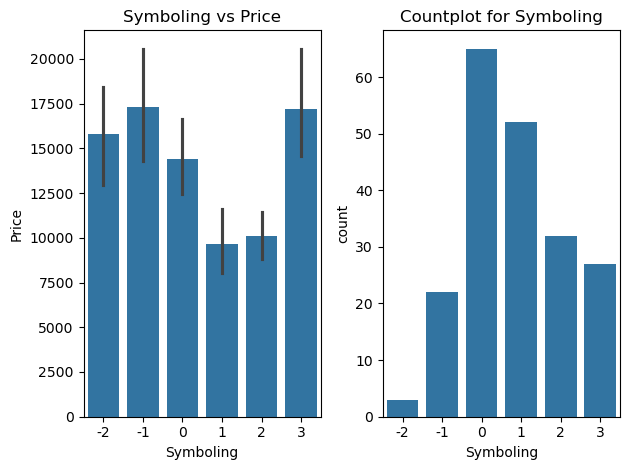

In [30]:
## Symboling vs Price

plt.subplot(1,2,1)
sns.barplot(x='Symboling', y='Price', data=data)
plt.title('Symboling vs Price')

plt.subplot(1,2,2)
sns.countplot(x='Symboling', data=data)
plt.title('Countplot for Symboling')
plt.tight_layout()
plt.show()

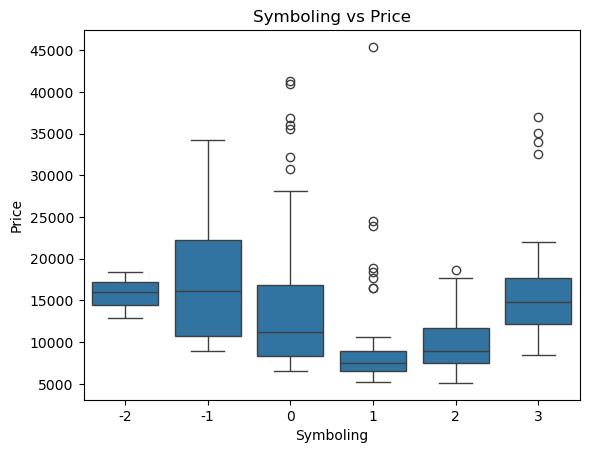

In [31]:
sns.boxplot(x='Symboling', y='Price', data=data)
plt.title('Symboling vs Price')
plt.show()

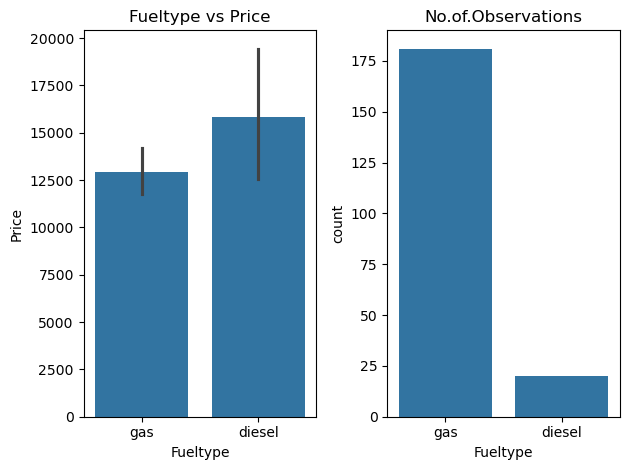

In [32]:
# Fueltype vs Price

plt.subplot(1,2,1)
sns.barplot(x='Fueltype', y='Price', data=data)
plt.title('Fueltype vs Price')

plt.subplot(1,2,2)
sns.countplot(x='Fueltype', data=data)
plt.title('No.of.Observations')
plt.tight_layout()
plt.show()

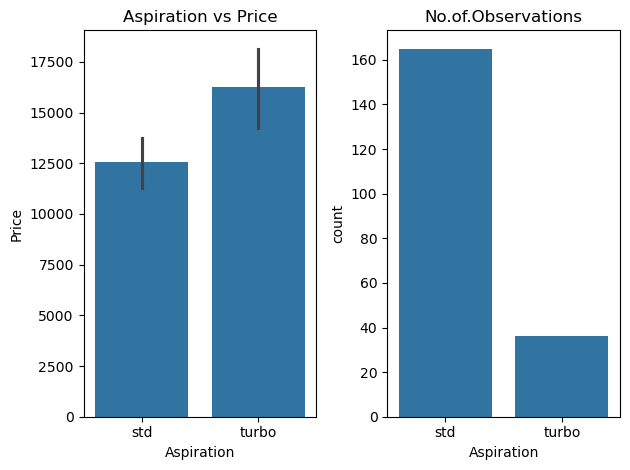

In [33]:
# Aspiration vs Price

plt.subplot(1,2,1)
sns.barplot(x='Aspiration', y='Price', data=data)
plt.title('Aspiration vs Price')

plt.subplot(1,2,2)
sns.countplot(x='Aspiration', data=data)
plt.title('No.of.Observations')
plt.tight_layout()
plt.show()

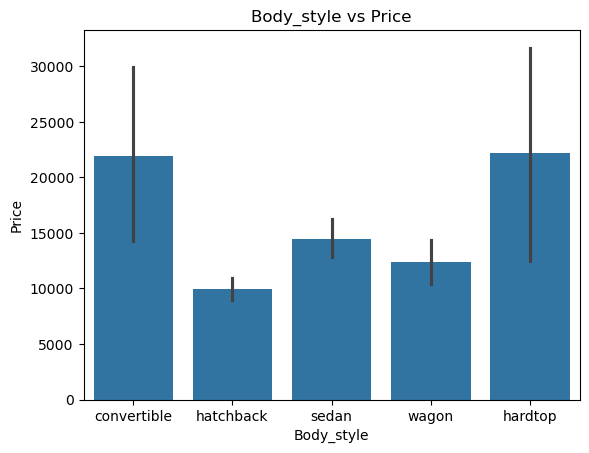

In [34]:
# Body_style vs Price

sns.barplot(x='Body_style', y='Price', data=data)
plt.title('Body_style vs Price')
plt.show()

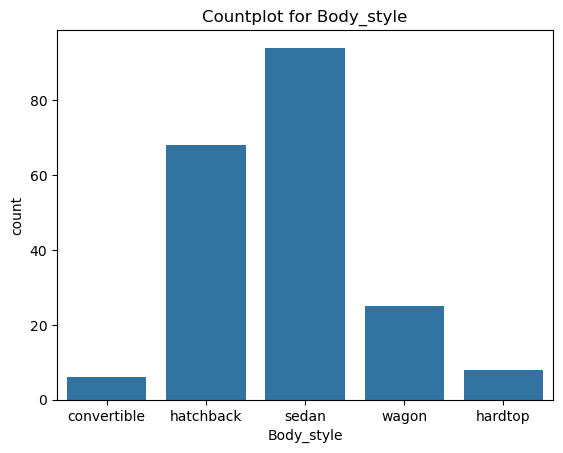

In [35]:
sns.countplot(x='Body_style', data=data)
plt.title('Countplot for Body_style')
plt.show()

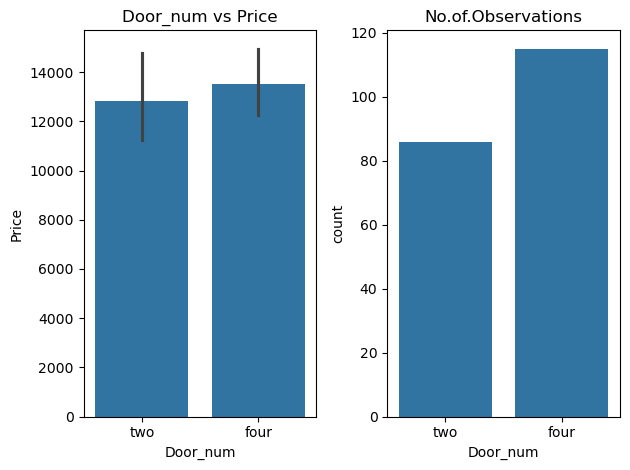

In [36]:
# Door_num vs Price

plt.subplot(1,2,1)
sns.barplot(x='Door_num', y='Price', data=data)
plt.title('Door_num vs Price')

plt.subplot(1,2,2)
sns.countplot(x='Door_num', data=data)
plt.title('No.of.Observations')
plt.tight_layout()
plt.show()

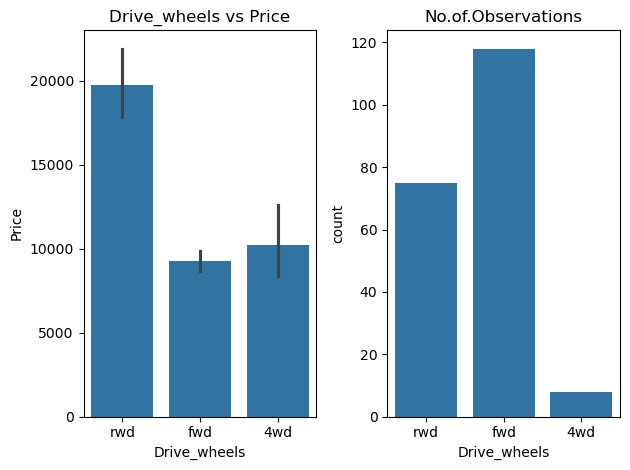

In [37]:
# Drive_wheels vs Price

plt.subplot(1,2,1)
sns.barplot(x='Drive_wheels', y='Price', data=data)
plt.title('Drive_wheels vs Price')

plt.subplot(1,2,2)
sns.countplot(x='Drive_wheels', data=data)
plt.title('No.of.Observations')
plt.tight_layout()
plt.show()

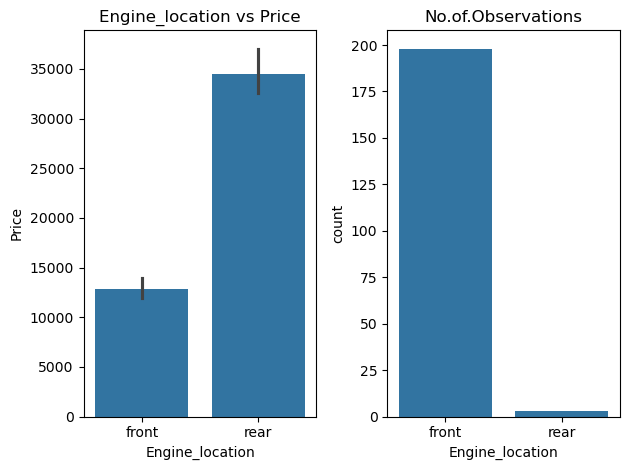

In [38]:
# Engine_location vs Price

plt.subplot(1,2,1)
sns.barplot(x='Engine_location', y='Price', data=data)
plt.title('Engine_location vs Price')

plt.subplot(1,2,2)
sns.countplot(x='Engine_location', data=data)
plt.title('No.of.Observations')
plt.tight_layout()
plt.show()

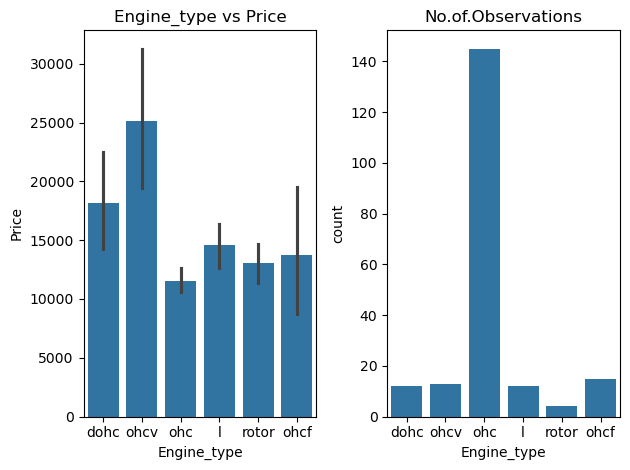

In [39]:
# Engine_type vs Price

plt.subplot(1,2,1)
sns.barplot(x='Engine_type', y='Price', data=data)
plt.title('Engine_type vs Price')

plt.subplot(1,2,2)
sns.countplot(x='Engine_type', data=data)
plt.title('No.of.Observations')
plt.tight_layout()
plt.show()

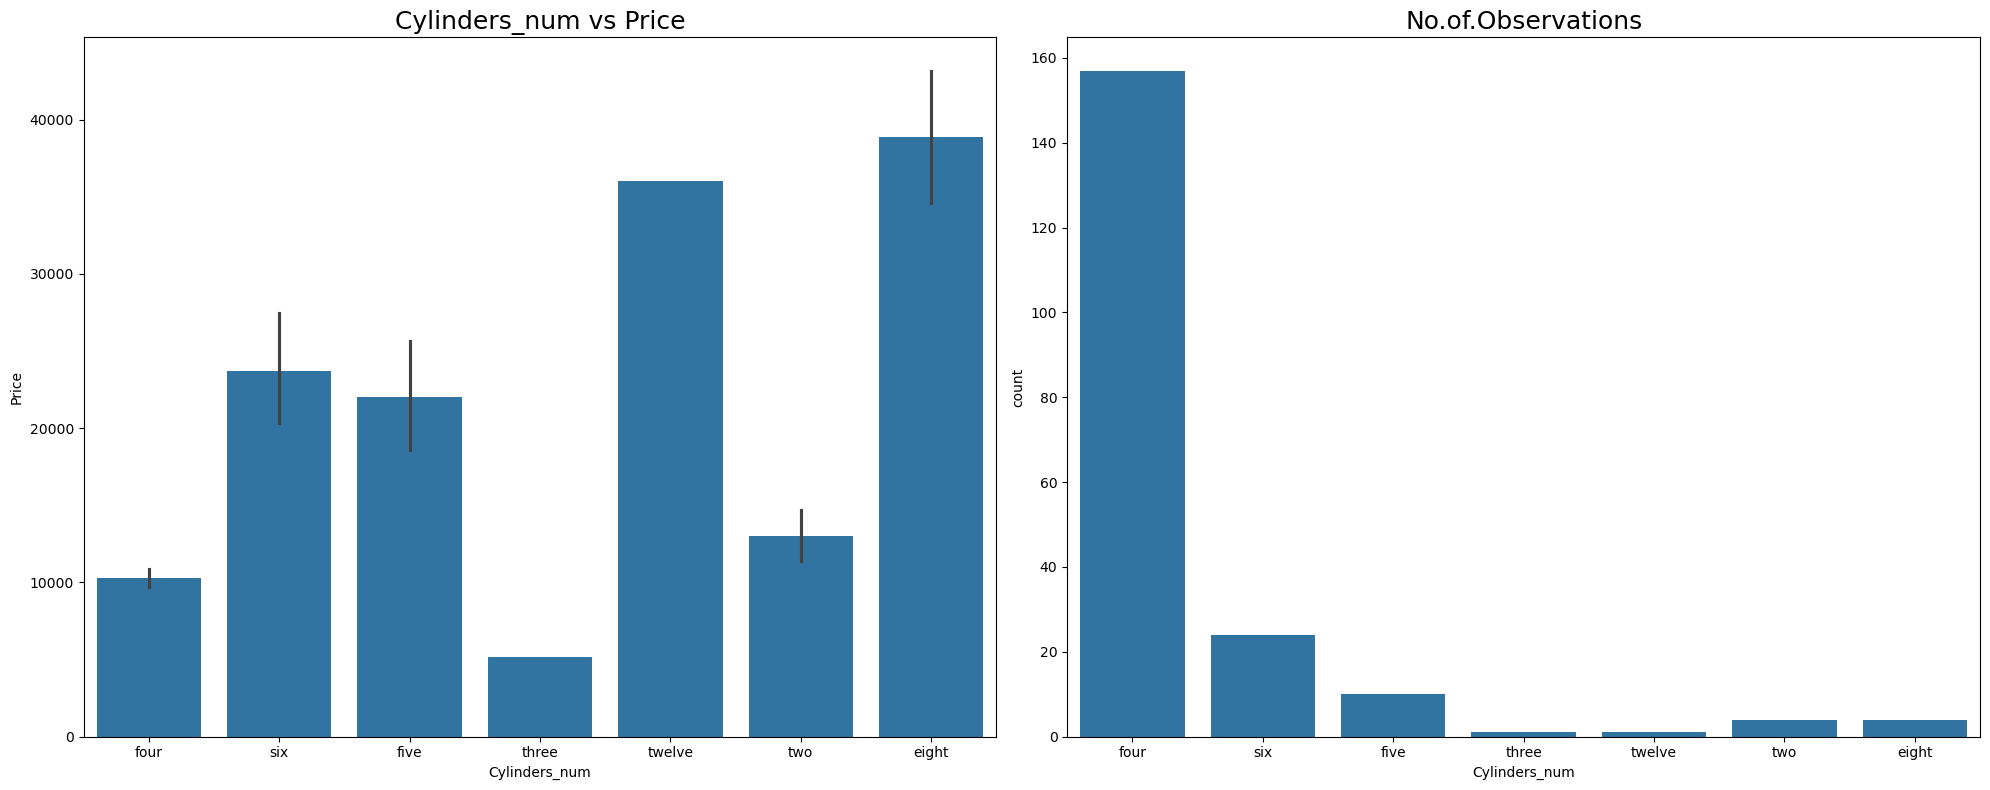

In [40]:
# Cylinders_num vs Price

plt.figure(figsize=(20,8))
plt.subplot(1,2,1)
sns.barplot(x='Cylinders_num', y='Price', data=data)
plt.title('Cylinders_num vs Price', size=18)

plt.subplot(1,2,2)
sns.countplot(x='Cylinders_num', data=data)
plt.title('No.of.Observations', size=18)
plt.tight_layout()
plt.show()

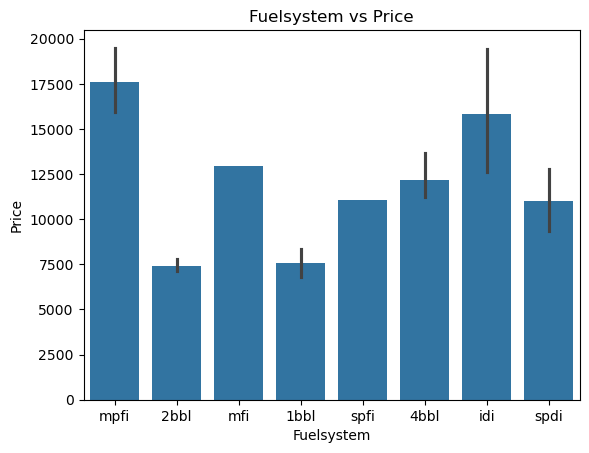

In [41]:
# Fuelsystem vs Price

sns.barplot(x='Fuelsystem', y='Price', data=data)
plt.title('Fuelsystem vs Price')
plt.show()

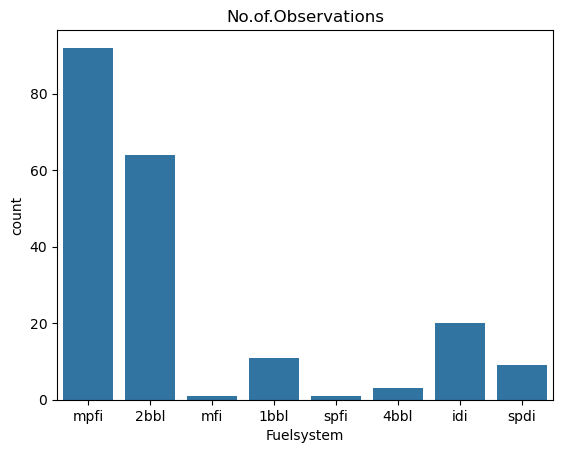

In [42]:
sns.countplot(x='Fuelsystem', data=data)
plt.title('No.of.Observations')
plt.show()

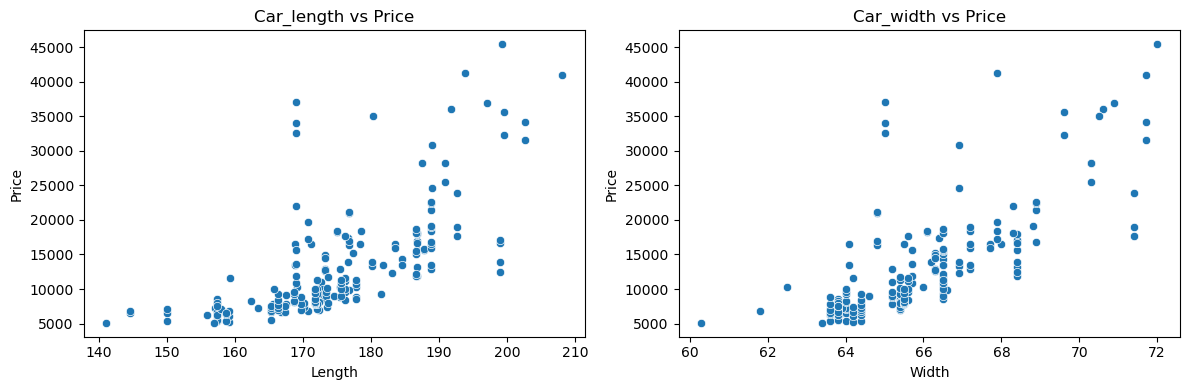

In [43]:
# Length vs Price

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.scatterplot(x='Length', y='Price', data=data)
plt.title('Car_length vs Price')


# Width vs Price

plt.subplot(1,2,2)
sns.scatterplot(x='Width', y='Price', data=data)
plt.title('Car_width vs Price')
plt.tight_layout()
plt.show()

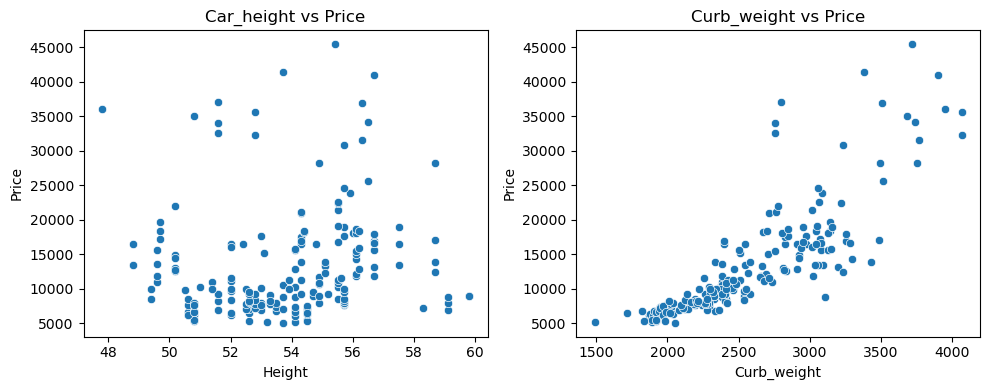

In [44]:
# Height vs Price

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.scatterplot(x='Height', y='Price', data=data)
plt.title('Car_height vs Price')


# Curb_weight vs Price

plt.subplot(1,2,2)
sns.scatterplot(x='Curb_weight', y='Price', data=data)
plt.title('Curb_weight vs Price')
plt.tight_layout()
plt.show()

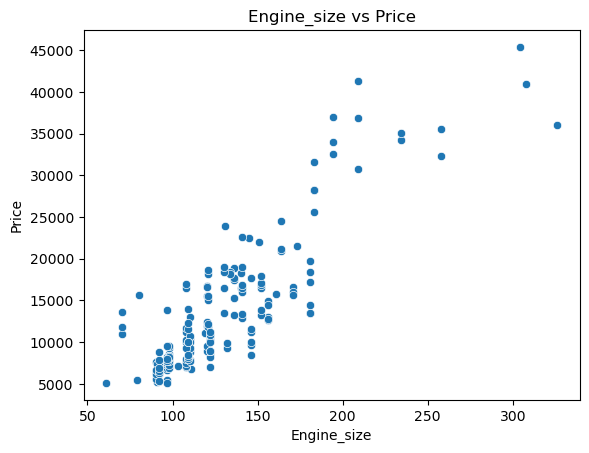

In [45]:
# Engine_size vs Price

sns.scatterplot(x='Engine_size', y='Price', data=data)
plt.title('Engine_size vs Price')
plt.show()

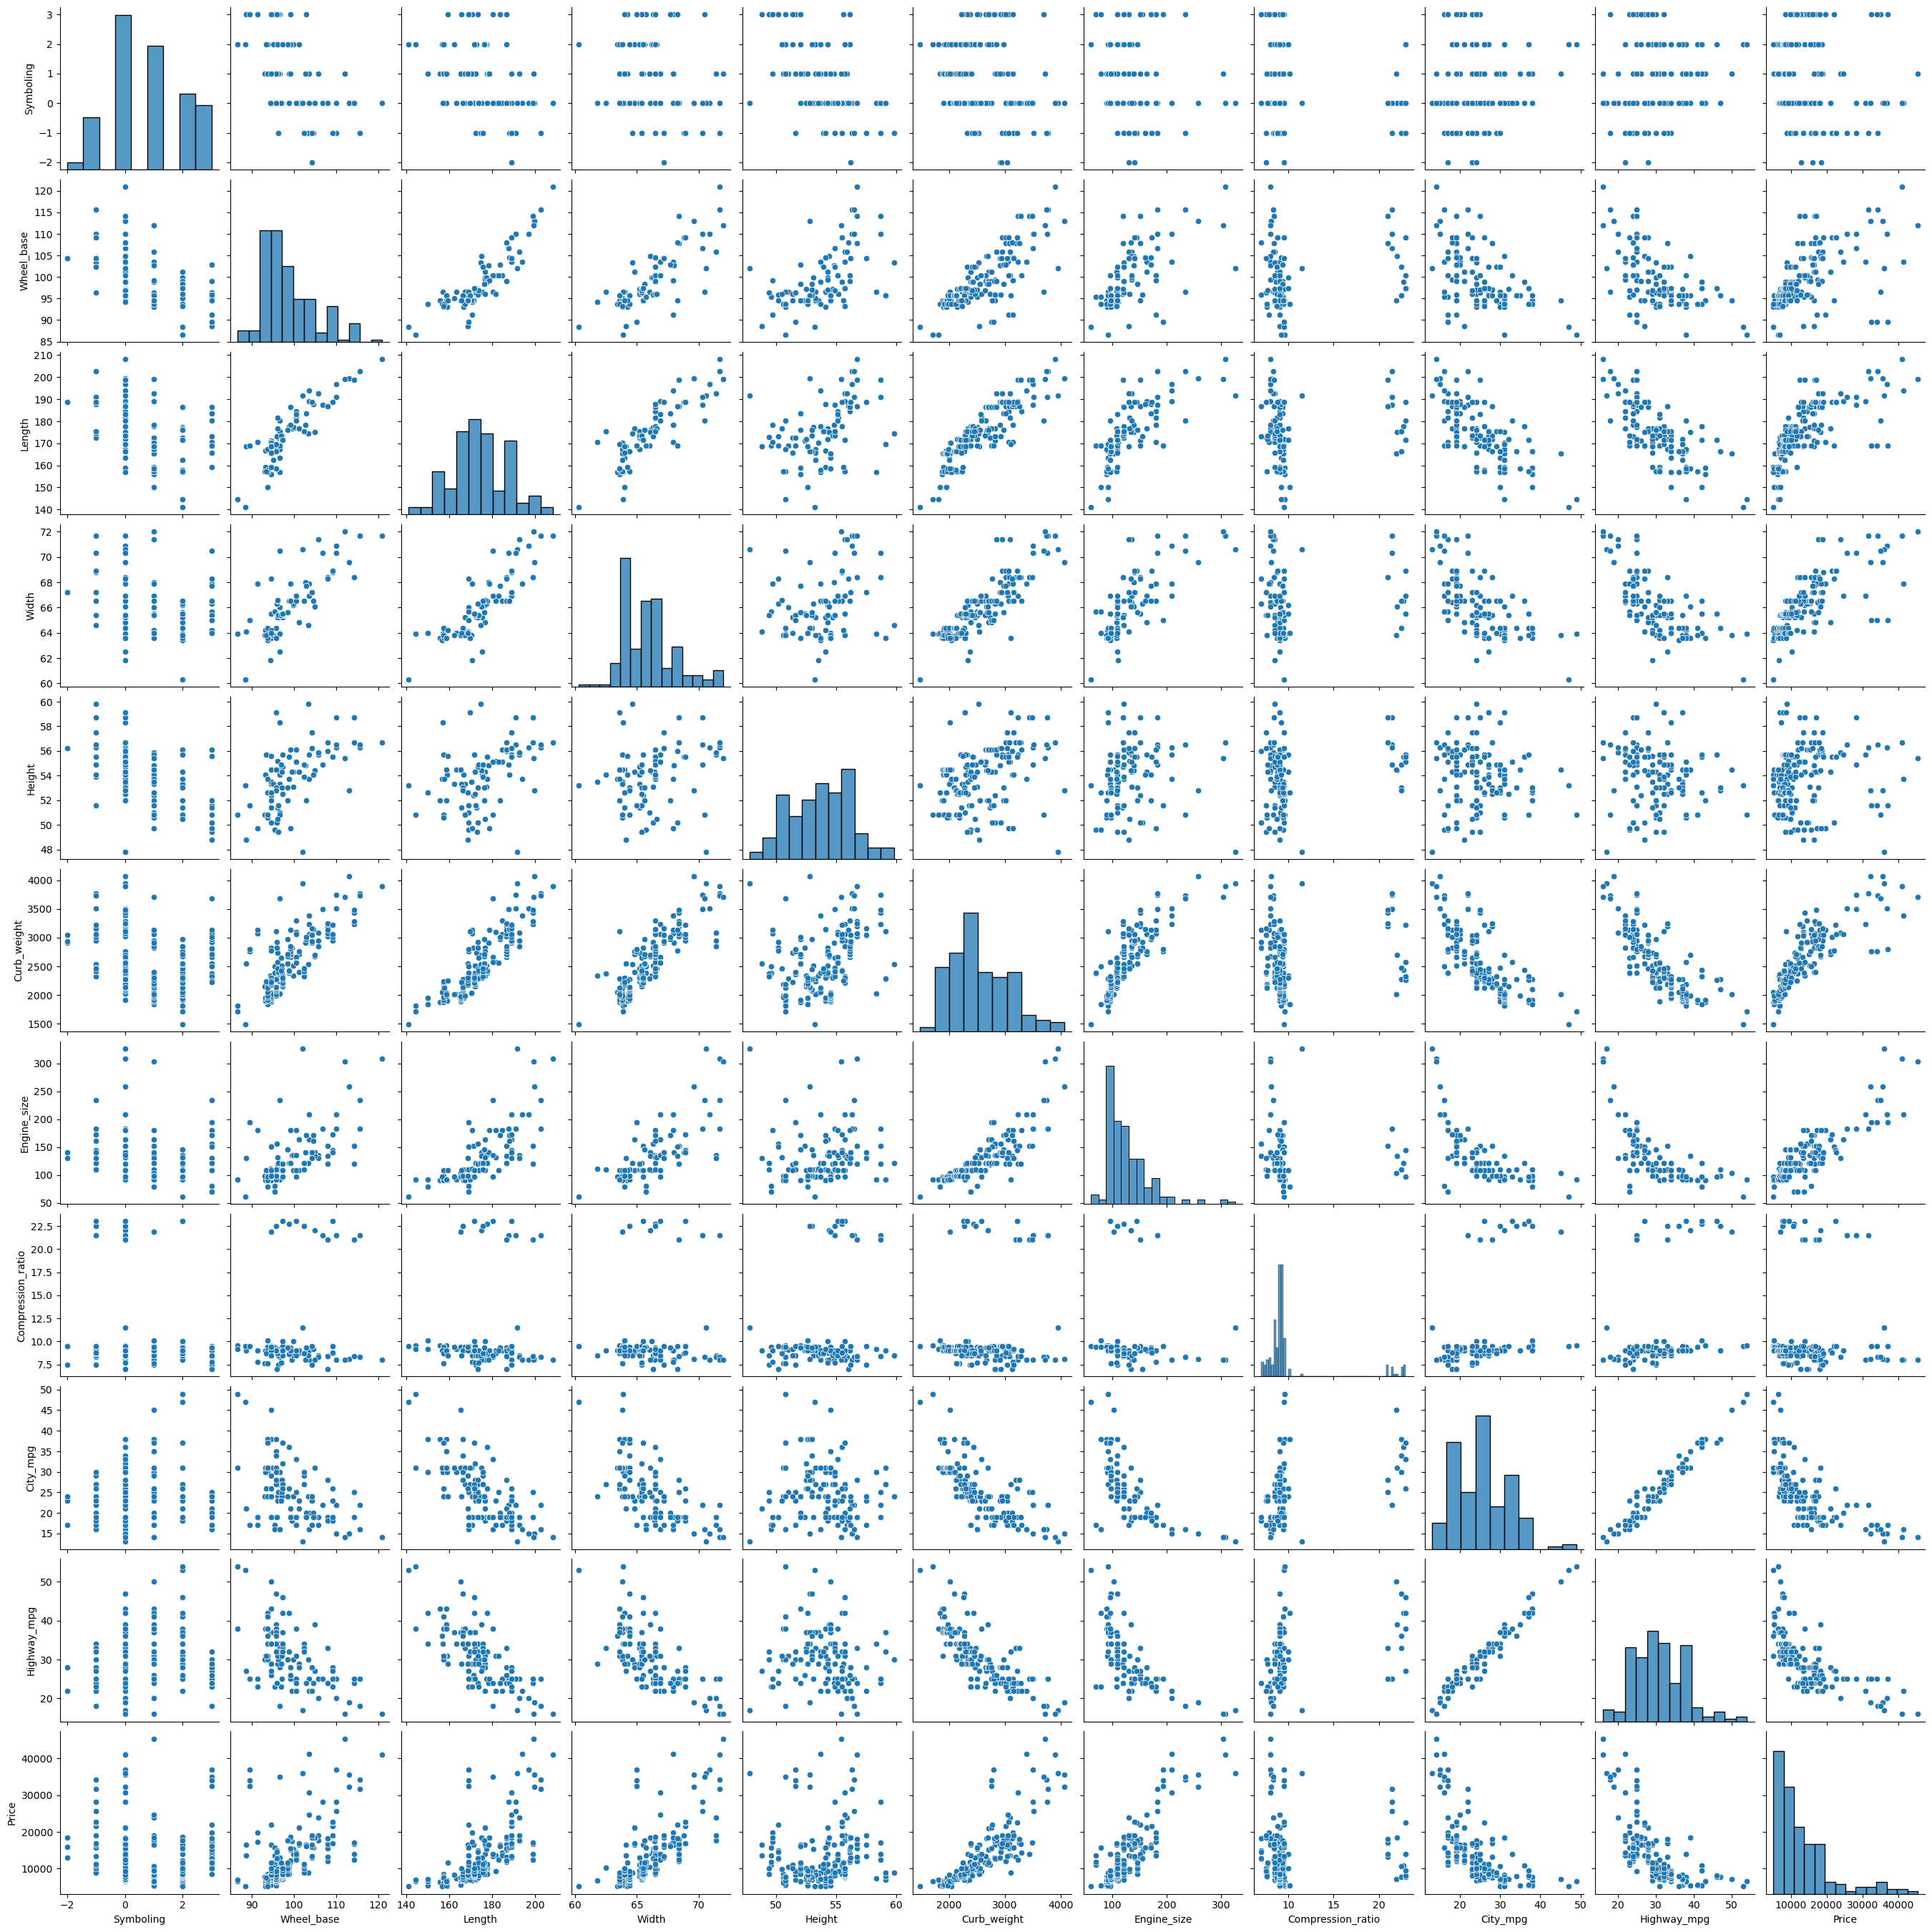

In [48]:
# Pairplot

sns.pairplot(data)
plt.show()

### Converting 'Horsepower','Peak_rpm' and 'Normalized_losses' columns datatype from object to float to perform EDA.

In [49]:
data[data['Horsepower']=='?'].index

Index([126, 127], dtype='int64')

In [50]:
data['Horsepower']=data['Horsepower'].replace('?','NaN')

In [51]:
data['Horsepower']= pd.to_numeric(data['Horsepower'], errors='coerce')

In [52]:
data['Horsepower'].mean()

103.39698492462311

In [53]:
data['Horsepower'].fillna(103.3, inplace= True)

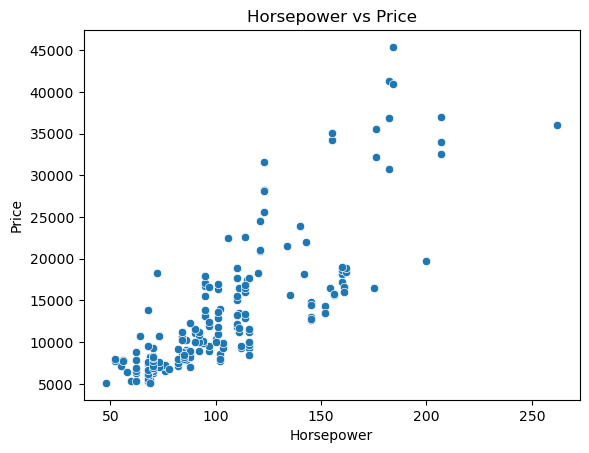

In [54]:
sns.scatterplot(x='Horsepower', y='Price', data=data)
plt.title('Horsepower vs Price')
plt.show()

In [55]:
data[data['Peak_rpm']=='?'].index

Index([126, 127], dtype='int64')

In [56]:
data['Peak_rpm']=data['Peak_rpm'].replace('?','NaN')

In [57]:
data['Peak_rpm']= pd.to_numeric(data['Peak_rpm'], errors='coerce')

In [58]:
data['Peak_rpm'].mean()

5117.587939698493

In [59]:
data['Peak_rpm'].fillna(5117.5, inplace= True)

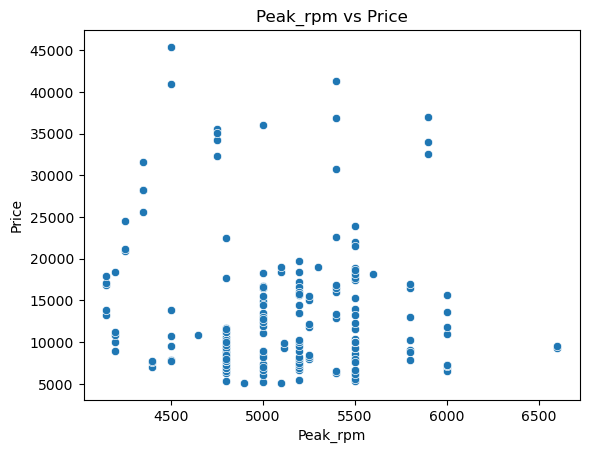

In [60]:
sns.scatterplot(x='Peak_rpm', y='Price', data=data)
plt.title('Peak_rpm vs Price')
plt.show()

In [61]:
data[data['Normalized_losses']=='?'].index

Index([  0,   1,   2,   5,   7,  13,  14,  15,  16,  42,  43,  45,  46,  60,
        63,  68,  70,  71,  72,  79,  80,  81, 106, 107, 110, 111, 121, 123,
       124, 125, 126, 127, 177, 185, 187, 188, 189],
      dtype='int64')

In [62]:
data['Normalized_losses']=data['Normalized_losses'].replace('?','NaN')

In [63]:
data['Normalized_losses']= pd.to_numeric(data['Normalized_losses'], errors='coerce')

In [64]:
data['Normalized_losses'].mean()

122.0

In [65]:
data['Normalized_losses'].fillna(122, inplace= True)

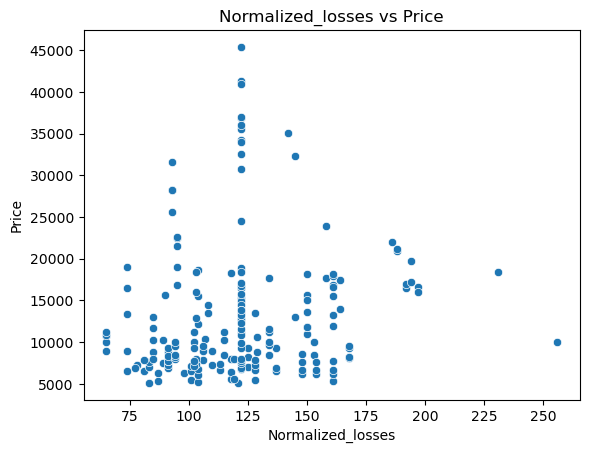

In [66]:
sns.scatterplot(x='Normalized_losses', y='Price', data=data)
plt.title('Normalized_losses vs Price')
plt.show()

### Converting 'Bore' and 'Stroke' columns datatype

In [67]:
# For Bore Column

data[data['Bore']=='?'].index

Index([52, 53, 54, 55], dtype='int64')

In [68]:
data['Bore']=data['Bore'].replace('?','NaN')
data['Bore']= pd.to_numeric(data['Bore'], errors='coerce')

In [69]:
data['Bore'].mean()

3.330710659898477

In [70]:
data['Bore'].fillna(3.33, inplace= True)

In [71]:
# For Stroke Column

data[data['Stroke']=='?'].index

Index([52, 53, 54, 55], dtype='int64')

In [72]:
data['Stroke']=data['Stroke'].replace('?','NaN')
data['Stroke']= pd.to_numeric(data['Stroke'], errors='coerce')

In [73]:
data['Stroke'].mean()

3.256903553299492

In [74]:
data['Stroke'].fillna(3.25, inplace= True)

In [75]:
data.dtypes

Symboling              int64
Normalized_losses    float64
Carname               object
Fueltype              object
Aspiration            object
Door_num              object
Body_style            object
Drive_wheels          object
Engine_location       object
Wheel_base           float64
Length               float64
Width                float64
Height               float64
Curb_weight            int64
Engine_type           object
Cylinders_num         object
Engine_size            int64
Fuelsystem            object
Bore                 float64
Stroke               float64
Compression_ratio    float64
Horsepower           float64
Peak_rpm             float64
City_mpg               int64
Highway_mpg            int64
Price                  int64
dtype: object

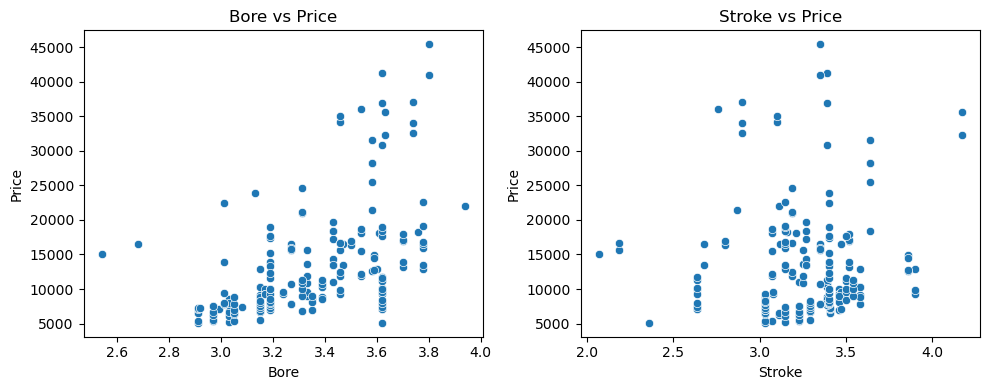

In [76]:
# Bore vs Price

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.scatterplot(x='Bore', y='Price', data=data)
plt.title('Bore vs Price')


# Stroke vs Price

plt.subplot(1,2,2)
sns.scatterplot(x='Stroke', y='Price', data=data)
plt.title('Stroke vs Price')
plt.tight_layout()
plt.show()

# Feature Engineering

## Encoding

In [77]:
data['Carname'].value_counts()

Carname
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
volkswagen       12
subaru           12
peugot           11
volvo            11
dodge             9
mercedes-benz     8
bmw               8
plymouth          7
audi              6
saab              6
porsche           4
jaguar            3
chevrolet         3
alfa-romero       3
isuzu             2
renault           2
mercury           1
Name: count, dtype: int64

In [78]:
data['Carname']= data['Carname'].map({'toyota': 0, 'nissan': 1, 'mazda': 2, 'mitsubishi': 3, 'honda': 4, 'volkswagen': 5, 'subaru': 6, 'peugot': 7,
                                      'volvo': 8, 'mercedes-benz': 9, 'dodge': 10, 'bmw': 11, 'plymouth': 12, 'audi': 13, 'saab': 14, 'porsche': 15,
                                      'jaguar': 16, 'chevrolet': 17, 'alfa-romero': 18, 'isuzu': 19, 'renault': 20, 'mercury': 21})

In [79]:
data['Fueltype'].value_counts()

Fueltype
gas       181
diesel     20
Name: count, dtype: int64

In [80]:
data['Fueltype']= data['Fueltype'].map({'gas': 0, 'diesel': 1})

In [81]:
data['Aspiration'].value_counts()

Aspiration
std      165
turbo     36
Name: count, dtype: int64

In [82]:
data['Aspiration']= data['Aspiration'].map({'std': 0, 'turbo': 1})

In [83]:
data['Door_num'].value_counts()

Door_num
four    115
two      86
Name: count, dtype: int64

In [84]:
data['Door_num']= data['Door_num'].map({'four': 0, 'two': 1})

In [85]:
data['Body_style'].value_counts()

Body_style
sedan          94
hatchback      68
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64

In [86]:
data['Body_style']= data['Body_style'].map({'sedan': 0, 'hatchback': 1, 'wagon': 2, 'hardtop': 3, 'convertible': 4})

In [87]:
data['Drive_wheels'].value_counts()

Drive_wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

In [88]:
data['Drive_wheels']= data['Drive_wheels'].map({'fwd': 0, 'rwd': 1, '4wd': 2})

In [89]:
data['Engine_location'].value_counts()

Engine_location
front    198
rear       3
Name: count, dtype: int64

In [90]:
data['Engine_location']= data['Engine_location'].map({'front': 0, 'rear': 1})

In [91]:
data['Engine_type'].value_counts()

Engine_type
ohc      145
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
Name: count, dtype: int64

In [92]:
data['Engine_type']= data['Engine_type'].map({'ohc': 0, 'ohcf': 1, 'ohcv': 2, 'dohc': 3, 'l': 4, 'rotor': 5})

In [93]:
data['Cylinders_num'].value_counts()

Cylinders_num
four      157
six        24
five       10
two         4
eight       4
three       1
twelve      1
Name: count, dtype: int64

In [94]:
data['Cylinders_num']= data['Cylinders_num'].map({'four': 0, 'six': 1, 'five': 2, 'two': 3, 'eight': 4, 'three': 5, 'twelve': 6})

In [95]:
data['Fuelsystem'].value_counts()

Fuelsystem
mpfi    92
2bbl    64
idi     20
1bbl    11
spdi     9
4bbl     3
mfi      1
spfi     1
Name: count, dtype: int64

In [96]:
data['Fuelsystem']= data['Fuelsystem'].map({'mpfi': 0, '2bbl': 1, 'idi':2, '1bbl': 3, 'spdi': 4, '4bbl': 5, 'mfi': 6, 'spfi': 7})

## Heatmap

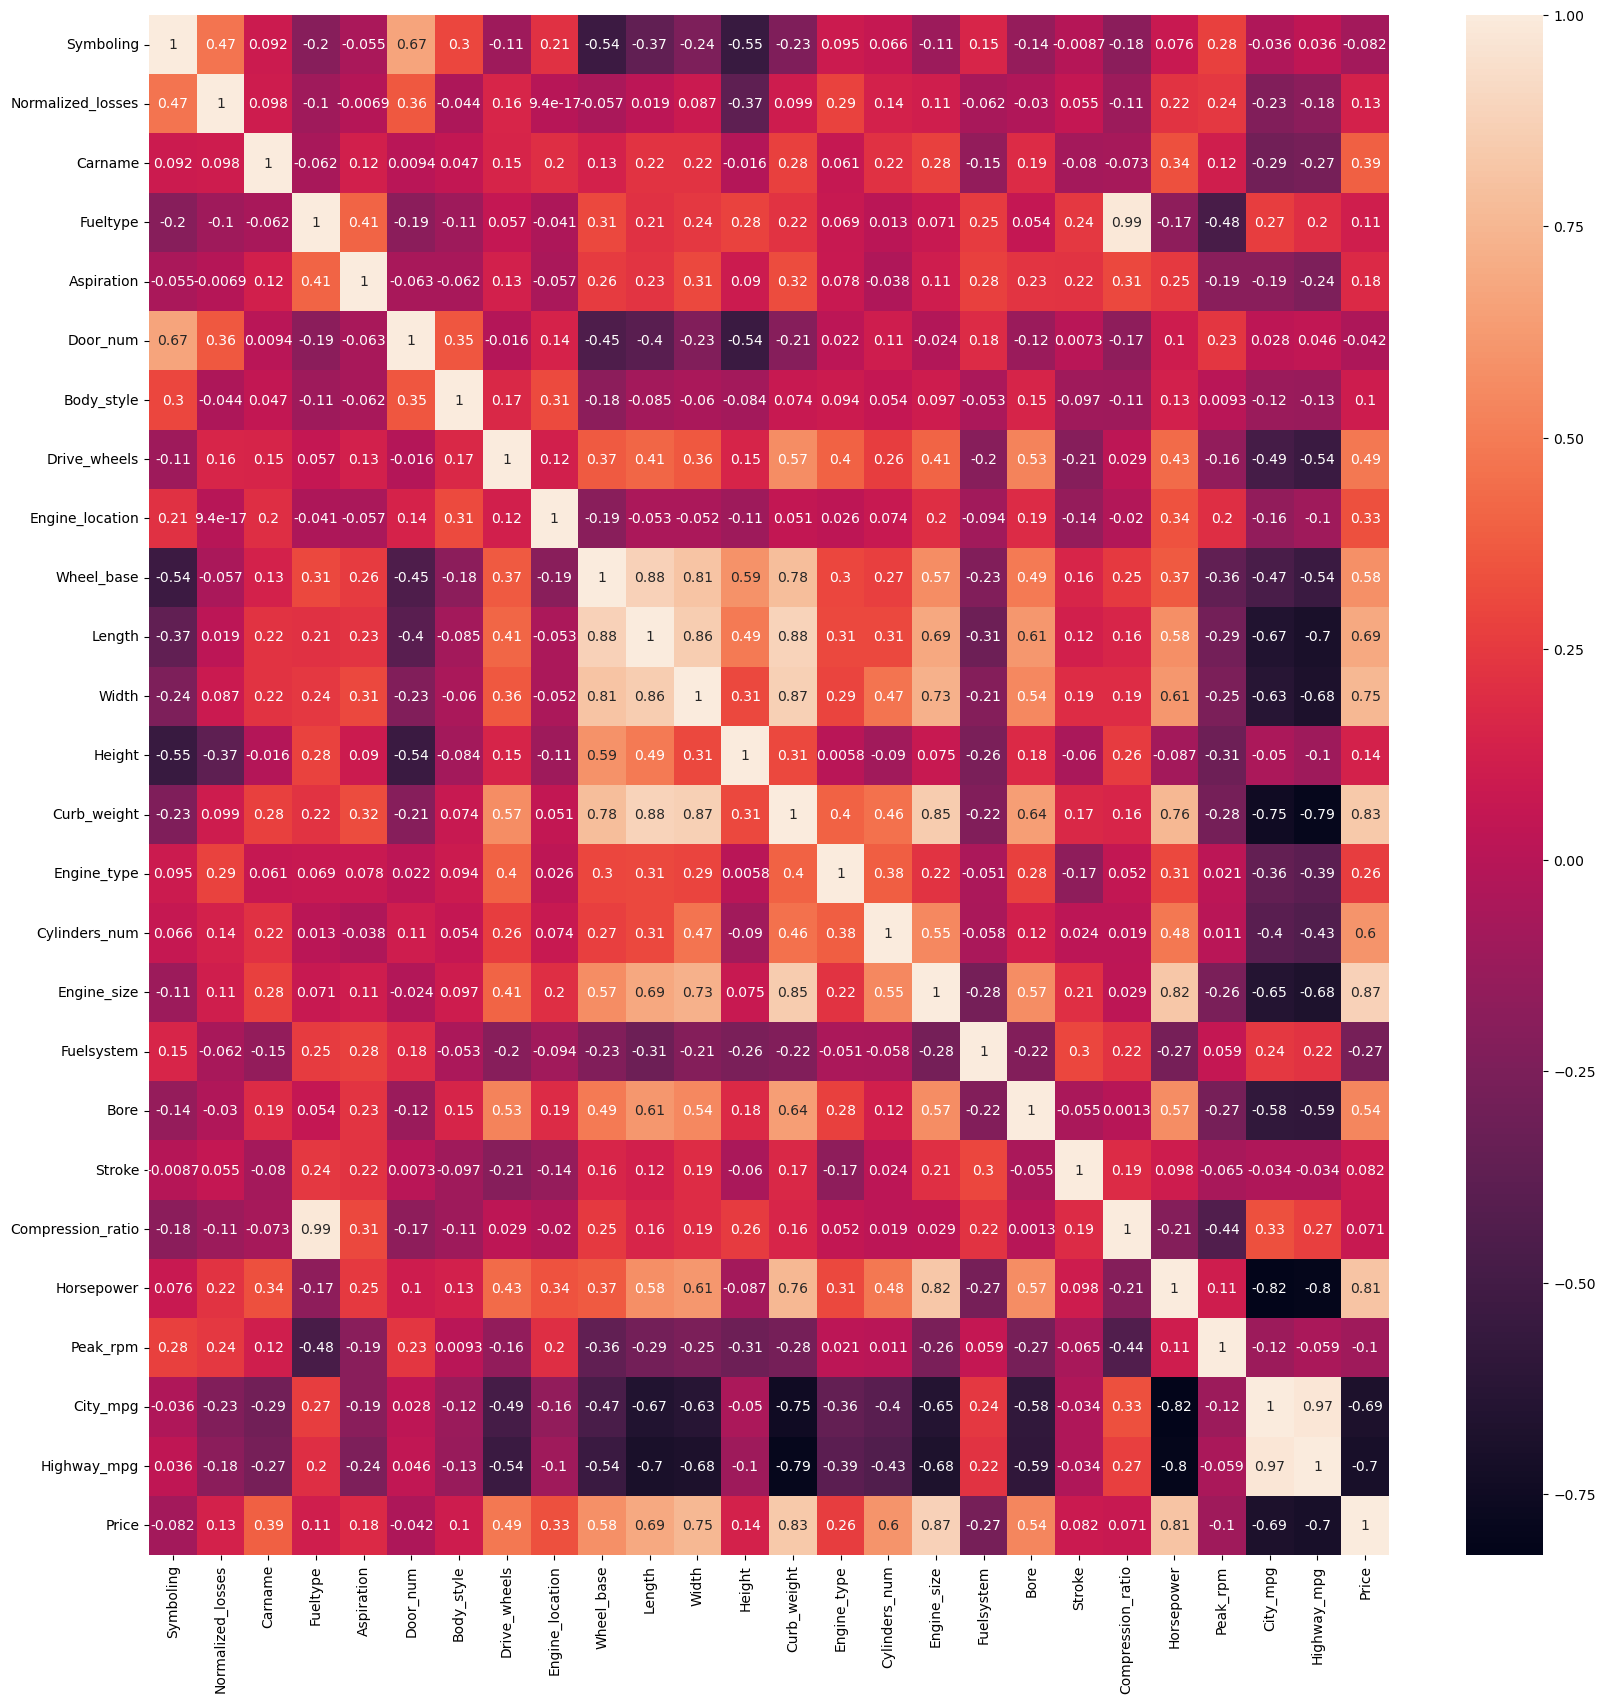

In [97]:
plt.figure(figsize=(20,20))
sns.heatmap(data.corr(), annot=True)
plt.show()

In [98]:
# Dropping Compression_ratio and Highway_mpg columns

data.drop(['Compression_ratio', 'Highway_mpg'], axis=1, inplace=True)

### Handling Outliers

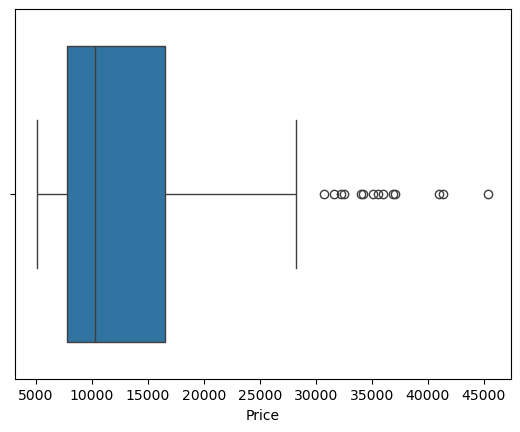

In [99]:
sns.boxplot(data=data, x='Price')
plt.show()

In [ ]:
## There are few Outliers starting from 30,00 price range. Here, we are not removing those outliers. Because some brand cars have high price which may 
#  start from 30000 or so. Hence we need those values too.

# Model Building

### Splitting data into Training and Testing sets 

In [100]:
# Splitting data into X and y  i.e., Independent and Dependent variable
X = data.drop(['Price'], axis=1)

In [101]:
y = data['Price']

In [102]:
X.head()

,Symboling,Normalized_losses,Carname,Fueltype,Aspiration,Door_num,Body_style,Drive_wheels,Engine_location,Wheel_base,...,Curb_weight,Engine_type,Cylinders_num,Engine_size,Fuelsystem,Bore,Stroke,Horsepower,Peak_rpm,City_mpg
0,3,122.0,18,0,0,1,4,1,0,88.6,...,2548,3,0,130,0,3.47,2.68,111.0,5000.0,21
1,3,122.0,18,0,0,1,4,1,0,88.6,...,2548,3,0,130,0,3.47,2.68,111.0,5000.0,21
2,1,122.0,18,0,0,1,1,1,0,94.5,...,2823,2,1,152,0,2.68,3.47,154.0,5000.0,19
3,2,164.0,13,0,0,0,0,0,0,99.8,...,2337,0,0,109,0,3.19,3.40,102.0,5500.0,24
4,2,164.0,13,0,0,0,0,2,0,99.4,...,2824,0,2,136,0,3.19,3.40,115.0,5500.0,18


In [103]:
y.head()

0    13495
1    16500
2    16500
3    13950
4    17450
Name: Price, dtype: int64

In [104]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Model Selection

We understood that it is a Regression problem for which we have to predict the Car Price. \
So, we can use Linear Regression Algorithm.

## Model Building

In [105]:
from sklearn.linear_model import LinearRegression

In [106]:
lr=LinearRegression()

In [107]:
lr.fit(X_train, y_train)

LinearRegression()

In [108]:
y_pred = lr.predict(X_test)

In [109]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## Model Evaluation

In [110]:
print('R2_Score:', r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2_Score: 0.8682552433000169
MAE: 2623.2030849576854
MSE: 16118545.852806885
RMSE: 4014.790885314811


## Actual vs Predicted graph

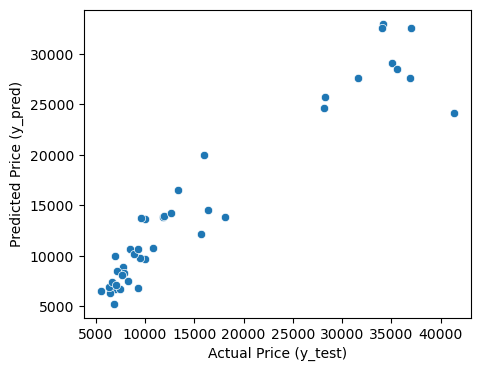

In [111]:
plt.figure(figsize=(5,4))

sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Price (y_test)')
plt.ylabel('Predicted Price (y_pred)')
plt.show()

# Save the model

In [ ]:
## Save the model to reuse it again

In [112]:
import pickle

In [113]:
# Open a file where you want to store the data and dump information into that file

with open('auto.pkl', 'wb') as f:
    pickle.dump(lr,f)

print('This model is saved as auto.pkl')

This model is saved as auto.pkl


In [114]:
## Load the model from file

with open('auto.pkl', 'rb') as f:
    loaded_model=pickle.load(f)

# Predicting the Car Price

In [115]:
test_data=pd.DataFrame({
    'Symboling': [-1,2],
    'Normalized_losses': [90,150],
    'Carname': [9,10],
    'Fueltype': [1,0],
    'Aspiration': [1,0],
    'Door_num': [0,1],
    'Body_style': [3,0],
    'Drive_wheels': [0,1],
    'Engine_location': [1,0],
    'Wheel_base': [110,99],
    'Length': [180,160],
    'Width': [66.9,63.8],
    'Height': [56.3,50.8],
    'Curb_weight': [3500,2120],
    'Engine_type': [0,2],
    'Cylinders_num': [6,1],
    'Engine_size': [171,145],
    'Fuelsystem': [0,2],
    'Bore': [3.30,2.95],
    'Stroke': [3.35,3.25],
    'Horsepower': [185,100],
    'Peak_rpm': [5100,5500],
    'City_mpg': [20,30]
})

In [116]:
test_data

,Symboling,Normalized_losses,Carname,Fueltype,Aspiration,Door_num,Body_style,Drive_wheels,Engine_location,Wheel_base,...,Curb_weight,Engine_type,Cylinders_num,Engine_size,Fuelsystem,Bore,Stroke,Horsepower,Peak_rpm,City_mpg
0,-1,90,9,1,1,0,3,0,1,110,...,3500,0,6,171,0,3.30,3.35,185,5100,20
1,2,150,10,0,0,1,0,1,0,99,...,2120,2,1,145,2,2.95,3.25,100,5500,30


In [117]:
# Making Predictions
predicted_price = loaded_model.predict(test_data)
print("Predicted Car Price:", predicted_price)

Predicted Car Price: [42673.20809575 14758.25915366]


# Final Report